In [1]:
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def group_data(dir_path: str):
    # Load the results
    files_to_read = [file for file in os.listdir(dir_path) if file.endswith('.csv')]
    pattern = r'agent_stats_run_(\d+)_ctr_(\d+\.?\d*)_alpha_(\d+\.?\d*)'
    files_per_alpha = {}
    for file in files_to_read:
        match = re.search(pattern, file)
        if match:
            alpha = float(match.group(3))
            if alpha not in files_per_alpha:
                files_per_alpha[alpha] = [file]
            else:
                files_per_alpha[alpha].append(file)
    # Load the results
    results = pd.DataFrame()
    for alpha, files in files_per_alpha.items():
        for file in files:
            curr_results = pd.read_csv(dir_path + file)
            curr_results['alpha'] = alpha
            results = pd.concat([results, curr_results])
    # Prima raggruppo per Run e Iteration per avere il dato aggregato per ogni iterazione
    grouped_results_run_iter = results.groupby(['alpha', 'Run', 'Iteration']) \
        .agg({'clicks': 'sum', 'impressions': 'sum', 'true_clicks': 'sum'}) \
        .reset_index()
    # Valori medi sulle run per ogni iterazione
    grouped_results = grouped_results_run_iter.groupby(['alpha', 'Iteration']).mean().reset_index()
    # intervallo di confidenza click
    grouped_results['clicks_std'] = grouped_results_run_iter.groupby(['alpha', 'Iteration']).std().reset_index()['clicks']
    grouped_results['clicks_ci'] = 1.96 * grouped_results['clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['alpha', 'Iteration']).count().reset_index()['clicks'])
    # intervallo di confidenza true_clicks
    grouped_results['true_clicks_std'] = grouped_results_run_iter.groupby(['alpha', 'Iteration']).std().reset_index()['true_clicks']
    grouped_results['true_clicks_ci'] = 1.96 * grouped_results['true_clicks_std'] / np.sqrt(grouped_results_run_iter.groupby(['alpha', 'Iteration']).count().reset_index()['true_clicks'])
    # intervallo di confidenza impressions
    grouped_results['impressions_std'] = grouped_results_run_iter.groupby(['alpha', 'Iteration']).std().reset_index()['impressions']
    grouped_results['impressions_ci'] = 1.96 * grouped_results['impressions_std'] / np.sqrt(grouped_results_run_iter.groupby(['alpha', 'Iteration']).count().reset_index()['impressions'])
    # Calcolo CTR e True CTR
    grouped_results['ctr'] = grouped_results['clicks'] / grouped_results['impressions']
    grouped_results['true_ctr'] = grouped_results['true_clicks'] / grouped_results['impressions']
    return grouped_results

In [7]:
def plot_mul_gr(gr_res_models, iteration=1, quantity='clicks', optimal_quantity=None, alpha_to_exclude=[]):
    # Prendo i valori unici di alpha da tutti i modelli
    unique_alphas = set()
    for gr_res in gr_res_models.values():
        unique_alphas.update(gr_res['alpha'].unique())
    plt.figure(figsize=(10, 6))
    for alpha in unique_alphas:
        if alpha_to_exclude and alpha in alpha_to_exclude:
            continue
        for model, gr_res in gr_res_models.items():
            if alpha not in gr_res['alpha'].unique():
                continue
            model_data = gr_res[(gr_res['Iteration']>iteration)&(gr_res['alpha'] == alpha)]
            plt.plot(model_data['Iteration'].to_numpy(), model_data[quantity].to_numpy(), label=f'{model} α={alpha}')
            if f'{quantity}_ci' in model_data.columns:
                plt.fill_between(model_data['Iteration'].to_numpy(), 
                                 model_data[quantity].to_numpy() -  model_data[f'{quantity}_ci'].to_numpy(), 
                                 model_data[quantity].to_numpy() +  model_data[f'{quantity}_ci'].to_numpy(), 
                                 alpha=0.5)
    if optimal_quantity:
        plt.axhline(y=optimal_quantity, color='r', linestyle='--', label=f'target {quantity}')
    plt.title(f'{quantity} mediati sulle run dall\'iterazione {iteration + 1}')
    plt.xlabel('Iteration')
    plt.ylabel(quantity)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [32]:
linucb_dir_path = '../results/FP_Truthful_Oracle_sigmoids_linucb_700iter_10run_14_11_24/'
linucb_gr_res = group_data(linucb_dir_path)

In [11]:
cucb_dir_path = '../results/FP_Truthful_Oracle_sigmoids_cucb_700iter_10run/'
cucb_gr_res = group_data(cucb_dir_path)

In [33]:
models = {'LinUCB': linucb_gr_res, 'CUCB': cucb_gr_res}

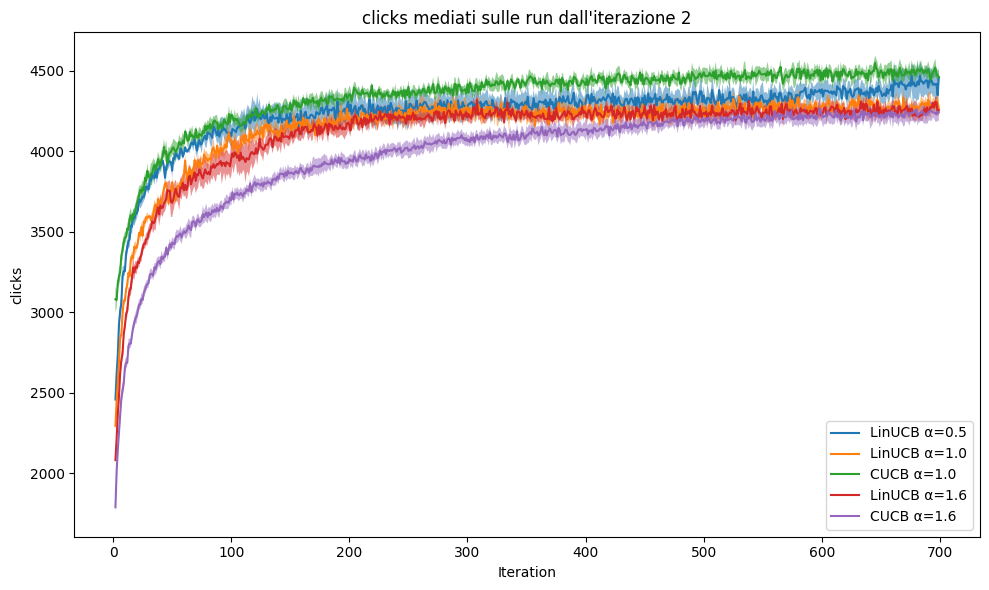

In [47]:
plot_mul_gr(models, iteration=1, quantity='clicks', alpha_to_exclude=[1.2, 2.0])

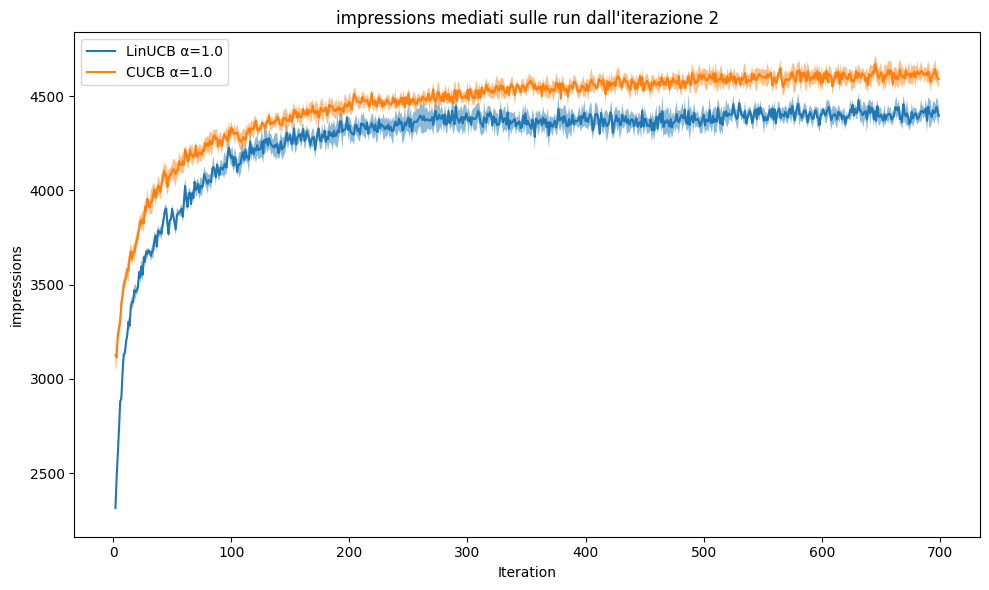

In [44]:
plot_mul_gr(models, iteration=1, quantity='impressions', alpha_to_exclude=[0.5, 1.2, 1.6, 2.0])

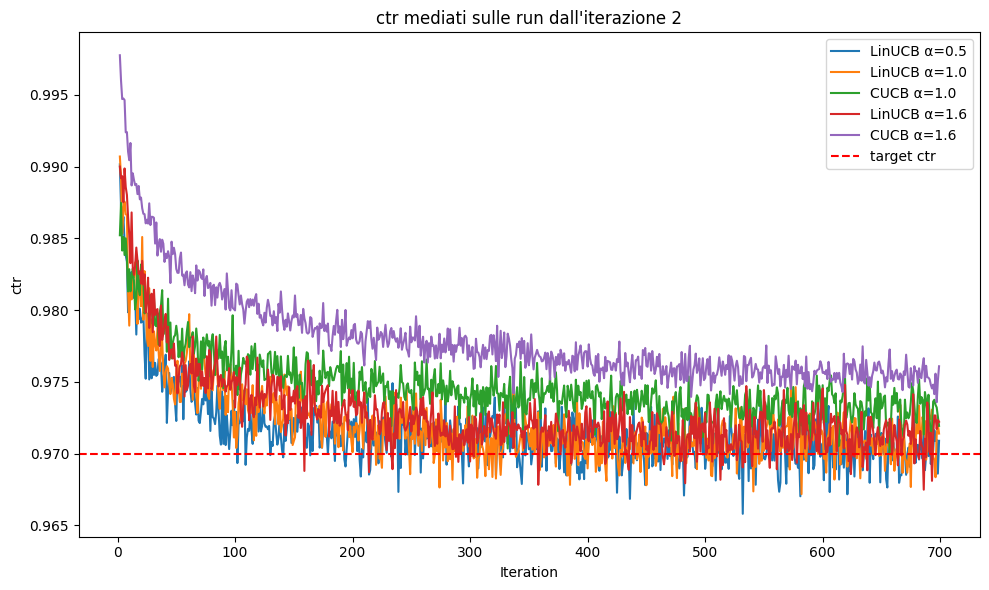

In [48]:
plot_mul_gr(models, iteration=1, quantity='ctr', alpha_to_exclude=[1.2, 2.0], optimal_quantity=0.97)

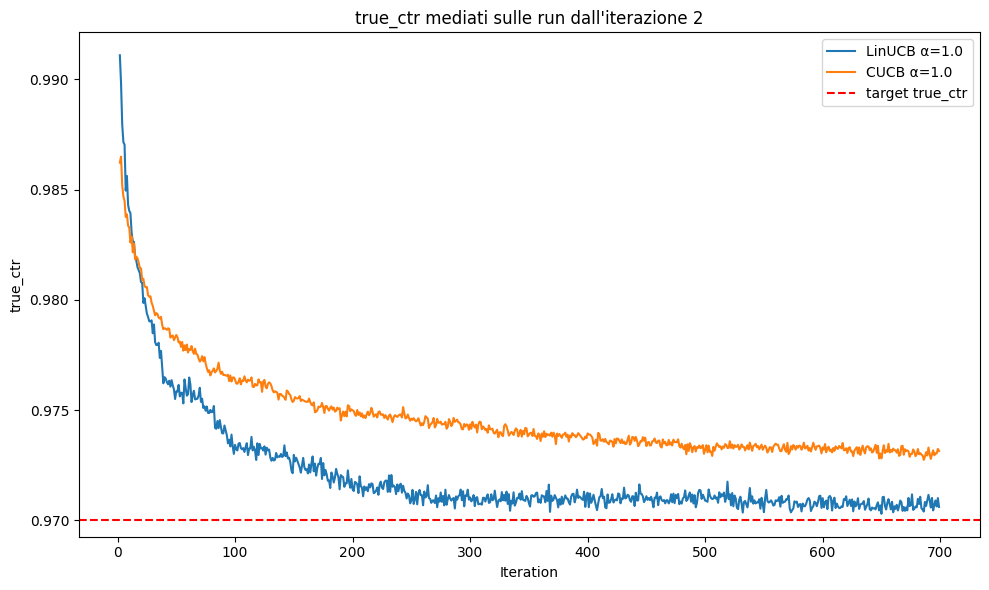

In [45]:
plot_mul_gr(models, iteration=1, quantity='true_ctr', alpha_to_exclude=[0.5, 1.2, 1.6, 2.0], optimal_quantity=0.97)